# ProteinMPNN — Inverse Folding

Visualization notebook: training curves, 3D backbone, sequence design, recovery vs temperature.

In [1]:
import re
import sys
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import torch

sys.path.insert(0, str(Path(".").resolve()))

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
from model import ProteinMPNN
from train import parse_pdb, AA_VOCAB

model = ProteinMPNN(dropout=0.0).to(device)
ckpt = torch.load("checkpoint.pt", map_location=device, weights_only=True)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"ProteinMPNN loaded: {model.count_parameters():,} parameters")

pdb = parse_pdb(Path("../data/pdb/1CRN.pdb"))
coords_N = pdb["coords_N"].to(device)
coords_CA = pdb["coords_CA"].to(device)
coords_C = pdb["coords_C"].to(device)
coords_O = pdb["coords_O"].to(device)
mask = pdb["mask"].to(device)
native_seq = pdb["sequence"]
L = coords_CA.shape[0]
print(f"1CRN: {L} residues")

ProteinMPNN loaded: 2,644,820 parameters
1CRN: 46 residues


## 1. Training Curves

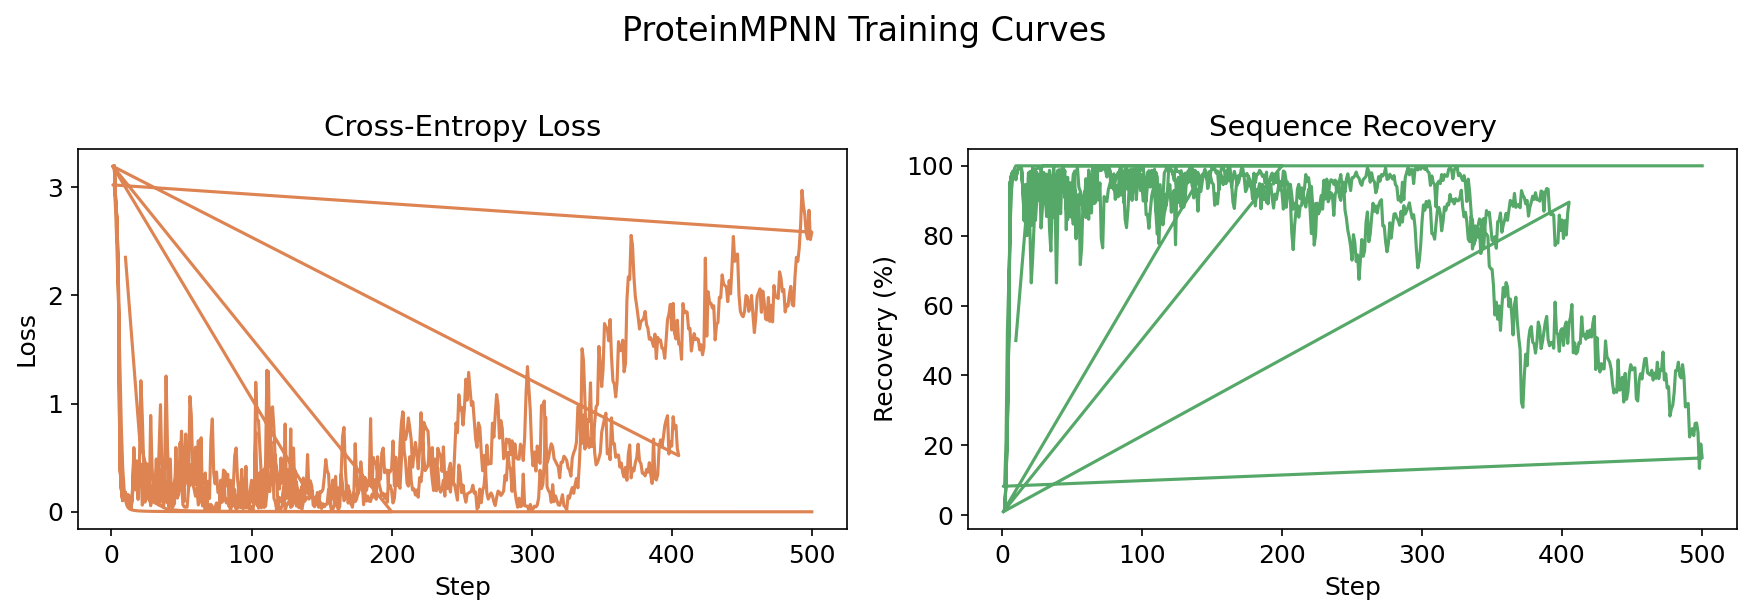

In [3]:
def parse_log(log_path, fields):
    """Parse training log. Returns dict of field_name -> list of floats."""
    data = {f: [] for f in fields}
    pattern = {f: re.compile(rf"{f}=([0-9eE.+-]+)") for f in fields}
    with open(log_path) as fh:
        for line in fh:
            if "step=" not in line:
                continue
            for f in fields:
                m = pattern[f].search(line)
                if m:
                    data[f].append(float(m.group(1)))
    return {f: np.array(v) for f, v in data.items()}


log = parse_log("../outputs/proteinmpnn/train.log", ["step", "loss", "recovery"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(log["step"], log["loss"], color="#DD8452")
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("Cross-Entropy Loss")

ax2.plot(log["step"], log["recovery"] * 100, color="#55A868")
ax2.set_xlabel("Step")
ax2.set_ylabel("Recovery (%)")
ax2.set_title("Sequence Recovery")

fig.suptitle("ProteinMPNN Training Curves", fontsize=16, y=1.02)
fig.tight_layout()
plt.show()

## 2. Training Data — 3D Backbone

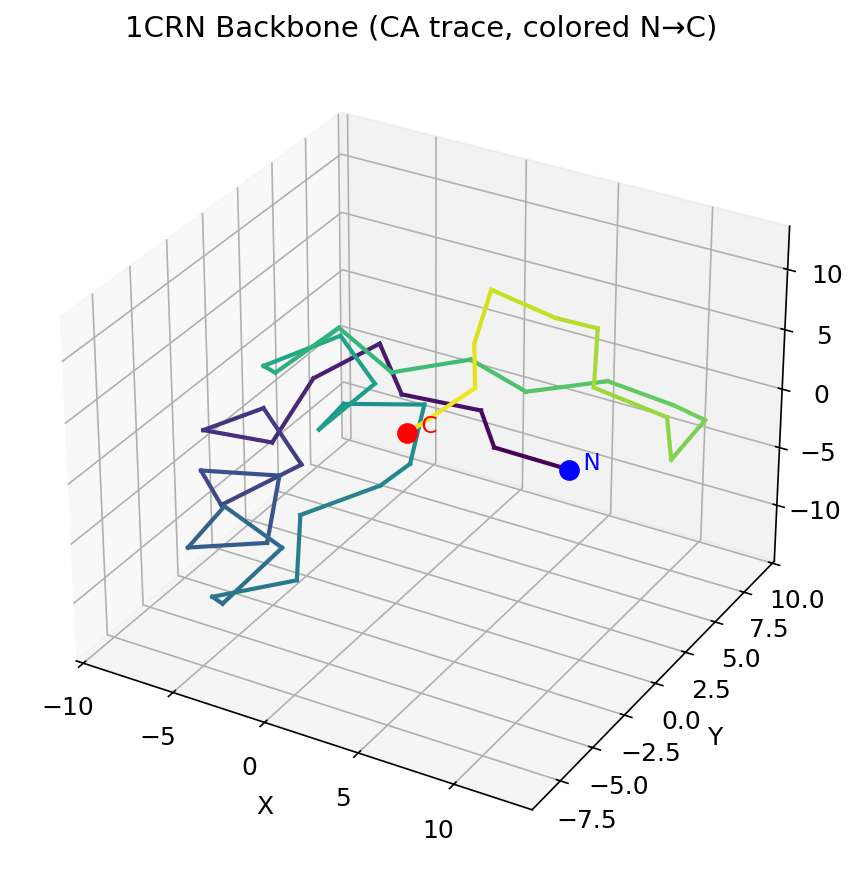

In [4]:
ca = coords_CA.cpu().numpy()
ca_centered = ca - ca.mean(axis=0)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
colors = plt.cm.viridis(np.linspace(0, 1, L))
for i in range(L - 1):
    ax.plot(ca_centered[i:i+2, 0], ca_centered[i:i+2, 1], ca_centered[i:i+2, 2],
            color=colors[i], linewidth=2)
ax.scatter(*ca_centered[0], color="blue", s=80, zorder=5)
ax.scatter(*ca_centered[-1], color="red", s=80, zorder=5)
ax.text(*ca_centered[0], "  N", fontsize=11, color="blue")
ax.text(*ca_centered[-1], "  C", fontsize=11, color="red")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("1CRN Backbone (CA trace, colored N→C)")
fig.tight_layout()
plt.show()

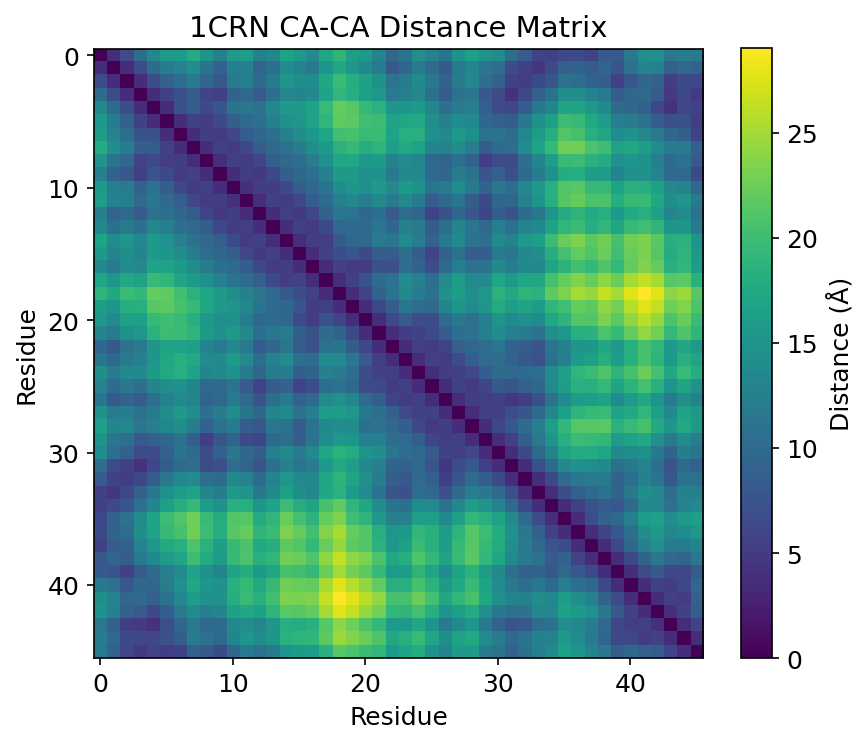

In [5]:
# CA-CA distance matrix
from scipy.spatial.distance import cdist

dist_matrix = cdist(ca, ca)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(dist_matrix, cmap="viridis")
ax.set_xlabel("Residue")
ax.set_ylabel("Residue")
ax.set_title("1CRN CA-CA Distance Matrix")
plt.colorbar(im, ax=ax, label="Distance (\u00c5)")
fig.tight_layout()
plt.show()

## 3. Sequence Design

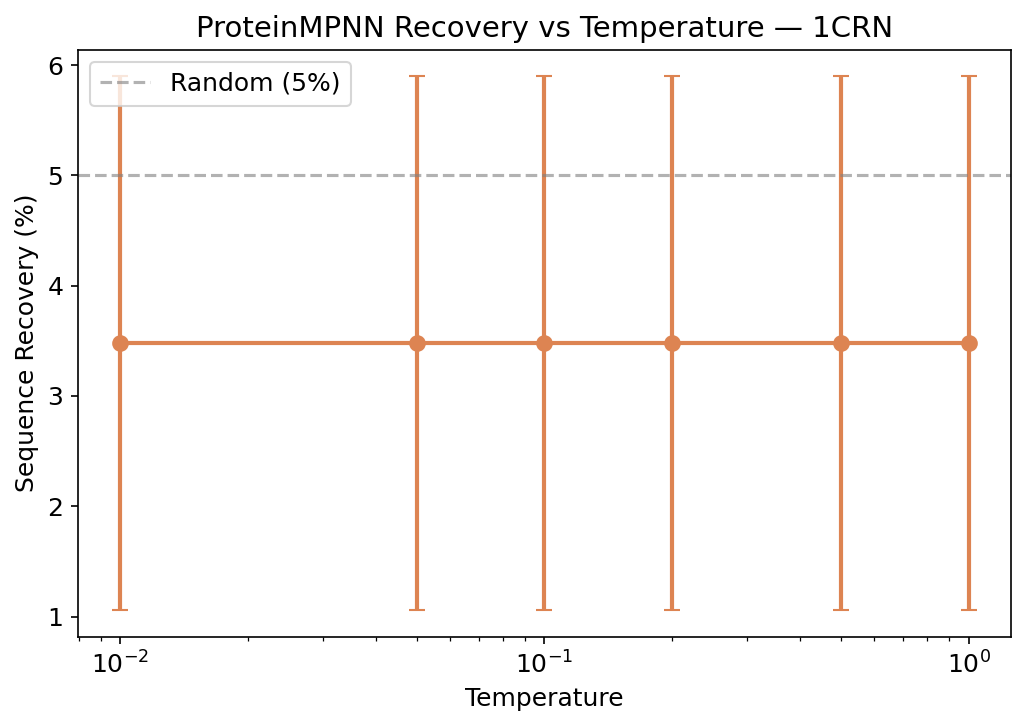

In [6]:
# Recovery vs temperature
temperatures = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
n_samples = 10
native = native_seq.cpu().numpy()
mean_recs, std_recs = [], []

for temp in temperatures:
    torch.manual_seed(0)
    seqs = model.design(coords_N, coords_CA, coords_C, coords_O, mask,
                        temperature=temp, num_samples=n_samples)
    recs = (seqs.cpu().numpy() == native[None, :]).mean(axis=1) * 100
    mean_recs.append(recs.mean())
    std_recs.append(recs.std())

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(temperatures, mean_recs, yerr=std_recs, fmt="o-", color="#DD8452",
            capsize=4, linewidth=2, markersize=7)
ax.axhline(y=100 / 20, color="gray", linestyle="--", alpha=0.6, label="Random (5%)")
ax.set_xscale("log")
ax.set_xlabel("Temperature")
ax.set_ylabel("Sequence Recovery (%)")
ax.set_title("ProteinMPNN Recovery vs Temperature — 1CRN")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Designed Sequences

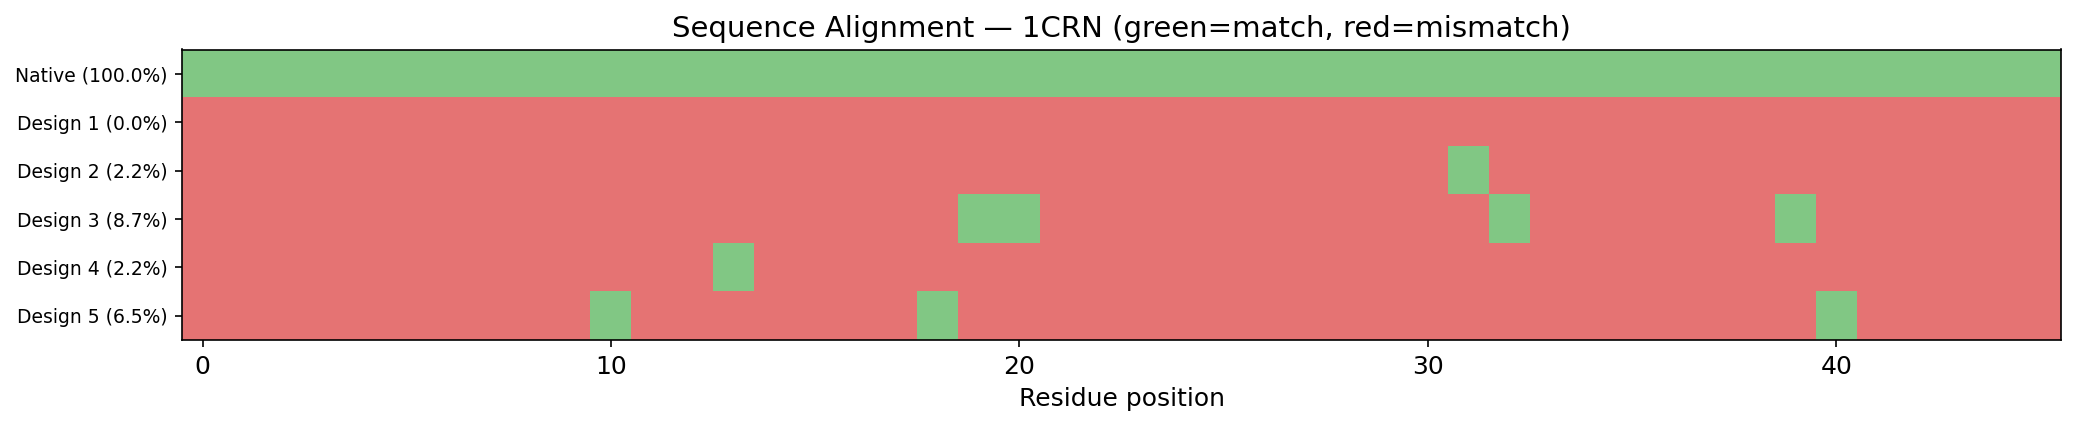

In [7]:
# Design at T=0.1 and show alignment heatmap
torch.manual_seed(42)
designs = model.design(coords_N, coords_CA, coords_C, coords_O, mask,
                       temperature=0.1, num_samples=5)  # [5, L]

all_seqs = np.vstack([native[None, :], designs.cpu().numpy()])  # [6, L]
match_matrix = (all_seqs == native[None, :]).astype(float)  # [6, L]

recoveries = [100.0]
for i in range(5):
    rec = (designs[i].cpu().numpy() == native).mean() * 100
    recoveries.append(rec)

fig, ax = plt.subplots(figsize=(14, 3))
cmap = matplotlib.colors.ListedColormap(["#E57373", "#81C784"])
ax.imshow(match_matrix, cmap=cmap, aspect="auto", interpolation="nearest")
row_labels = ["Native (100.0%)"]
for i in range(5):
    row_labels.append(f"Design {i + 1} ({recoveries[i + 1]:.1f}%)")
ax.set_yticks(range(6))
ax.set_yticklabels(row_labels, fontsize=9)
ax.set_xlabel("Residue position")
ax.set_title("Sequence Alignment — 1CRN (green=match, red=mismatch)")
fig.tight_layout()
plt.show()

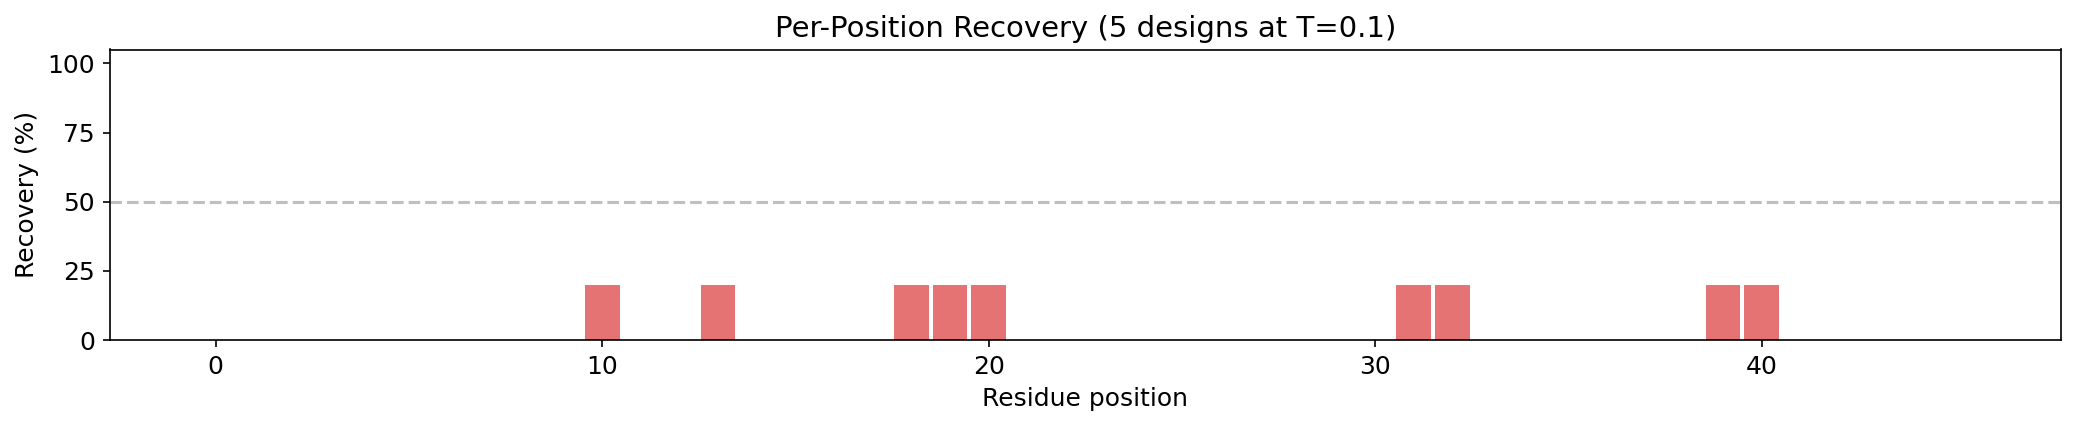

In [8]:
# Per-position recovery across designs
per_pos_recovery = (designs.cpu().numpy() == native[None, :]).mean(axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 3))
colors = ["#81C784" if r > 50 else "#E57373" for r in per_pos_recovery]
ax.bar(range(L), per_pos_recovery, color=colors, width=0.9)
ax.axhline(y=50, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Residue position")
ax.set_ylabel("Recovery (%)")
ax.set_title("Per-Position Recovery (5 designs at T=0.1)")
ax.set_ylim(0, 105)
fig.tight_layout()
plt.show()